In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

In [36]:
import datetime as dt
import yfinance as yf

start = dt.datetime(2021, 7, 1)
end = dt.datetime(2022, 1, 27)

symbol = "INFY.NS"
stock_df = yf.download(symbol, start=start, end=end)

stock_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2021-07-01,1359.065674,1373.393131,1357.889882,1373.393131,4814317
2021-07-02,1365.510620,1366.947640,1343.562051,1357.802429,5166064
2021-07-05,1375.221802,1380.491227,1359.631481,1366.686336,4058338
2021-07-06,1360.633423,1382.015844,1356.191484,1370.649608,4089574
2021-07-07,1362.723633,1367.905983,1345.347773,1363.986607,4797120


In [37]:
scaler = MinMaxScaler()
close_data = scaler.fit_transform(stock_df[["Close"]])
print(close_data.shape)

(143, 1)


In [38]:
def rmse_mape(actual,pred):
    rmse=np.sqrt(mean_squared_error(actual,pred))
    mape=np.mean(np.abs((actual-pred)/actual))*100
    return rmse,mape

In [39]:
orders=[(1,1,1),(2,1,1),(2,1,2),(3,1,1)]
result=[]
for order in orders:
    model=ARIMA(close_data,order=order)
    model_fit=model.fit()
    prediction=model_fit.predict(0,len(close_data)-1)
    rmse,mape=rmse_mape(close_data.flatten(),prediction)
    result.append([order,rmse,mape])
results=pd.DataFrame(result,columns=["Order","RMSE","MAPE"])
results

C:\Users\Paul\AppData\Local\Temp\ipykernel_10548\2158674666.py:3: RuntimeWarning: divide by zero encountered in divide
  mape=np.mean(np.abs((actual-pred)/actual))*100
C:\Users\Paul\AppData\Local\Temp\ipykernel_10548\2158674666.py:3: RuntimeWarning: divide by zero encountered in divide
  mape=np.mean(np.abs((actual-pred)/actual))*100
c:\Users\Paul\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Paul\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Paul\AppData\Local\Temp\ipykernel_10548\2158674666.py:3: RuntimeWarning: divide by zero encountered in divide
  mape=np.mean(np.abs((actual-pred)/actual))*100
C:\Users\Paul

,Order,RMSE,MAPE
0,"(1, 1, 1)",0.053459,inf
1,"(2, 1, 1)",0.053460,inf
2,"(2, 1, 2)",0.053448,inf
3,"(3, 1, 1)",0.053449,inf


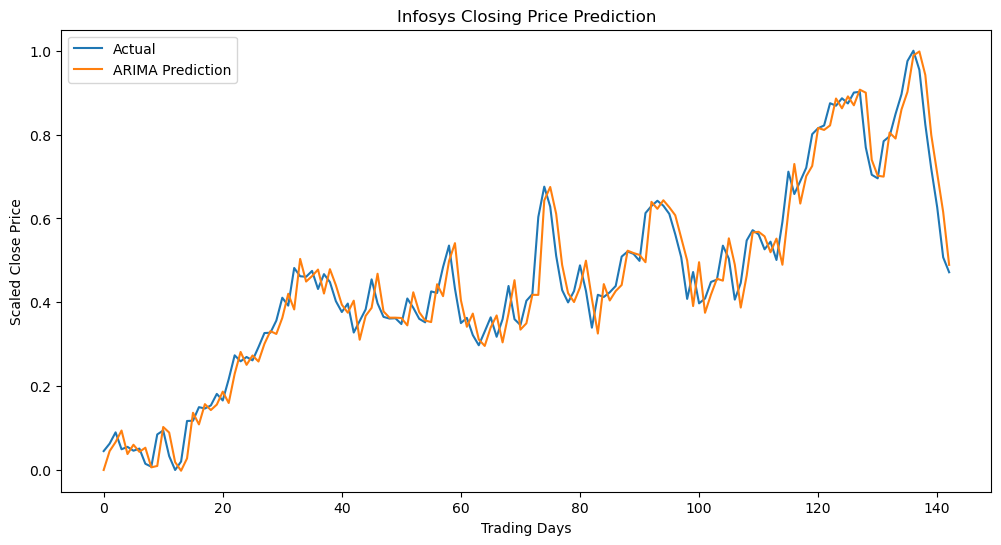

In [40]:
best_model=ARIMA(close_data,order=(2,1,1))
model_fit=best_model.fit()
prediction=model_fit.predict(0,len(close_data)-1)
plt.figure(figsize=(12,6))
plt.plot(close_data,label="Actual")
plt.plot(prediction,label="ARIMA Prediction")
plt.title("Infosys Closing Price Prediction")
plt.xlabel("Trading Days")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

In [41]:
len(close_data)

143

In [42]:
actual=scaler.inverse_transform(close_data)
pred=scaler.inverse_transform(prediction.reshape(-1,1))
actual_df=pd.DataFrame(actual,columns=["Actual Close"])
pred_df=pd.DataFrame(pred,columns=["Predicted Close"])

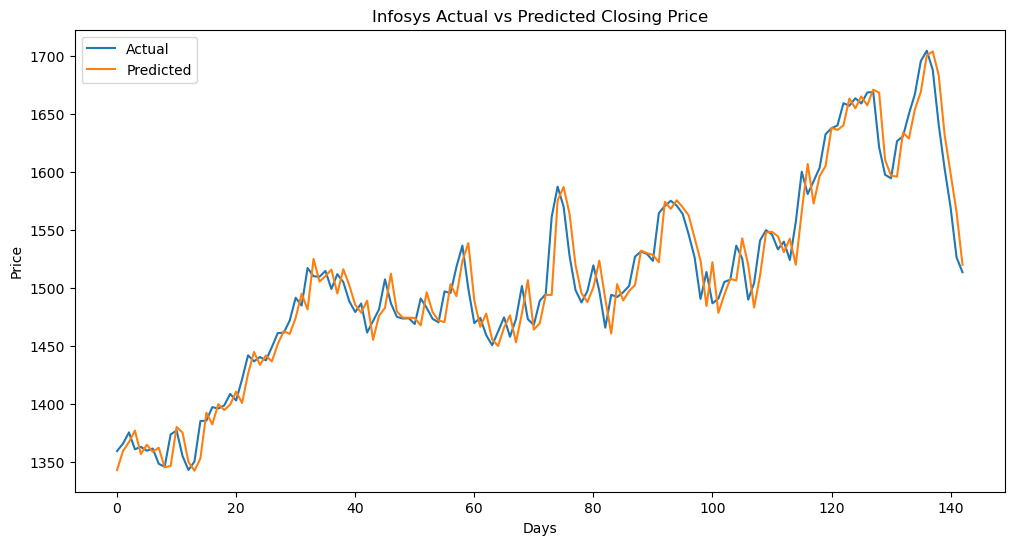

In [43]:
plt.figure(figsize=(12,6))
plt.plot(actual_df["Actual Close"],label="Actual")
plt.plot(pred_df["Predicted Close"],label="Predicted")
plt.title("Infosys Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [44]:
rmse,mape=rmse_mape(actual_df["Actual Close"],pred_df["Predicted Close"])
print("RMSE =",rmse)
print("MAPE =",mape)

RMSE = 19.322930314016617
MAPE = 1.0066559524260132


In [45]:
forecast=model_fit.predict(len(close_data),len(close_data)+7)
forecast

array([0.47459031, 0.47851185, 0.4791081 , 0.47888124, 0.47877637,
       0.47877389, 0.47878294, 0.47878518])

In [46]:
forecast_df=pd.DataFrame(forecast,columns=["Forecast"])

forecast_actual=scaler.inverse_transform(forecast_df)
forecast_final=pd.DataFrame(
forecast_actual,columns=["Forecast Close"])

forecast_final

,Forecast Close
0,1514.316017
1,1515.733432
2,1515.948941
3,1515.866945
4,1515.829040
5,1515.828145
6,1515.831417
7,1515.832224


In [47]:
forecast_final.to_csv("Infosys_ARIMA_Forecast.csv",index=False)

In [48]:
forecast_final

,Forecast Close
0,1514.316017
1,1515.733432
2,1515.948941
3,1515.866945
4,1515.829040
5,1515.828145
6,1515.831417
7,1515.832224


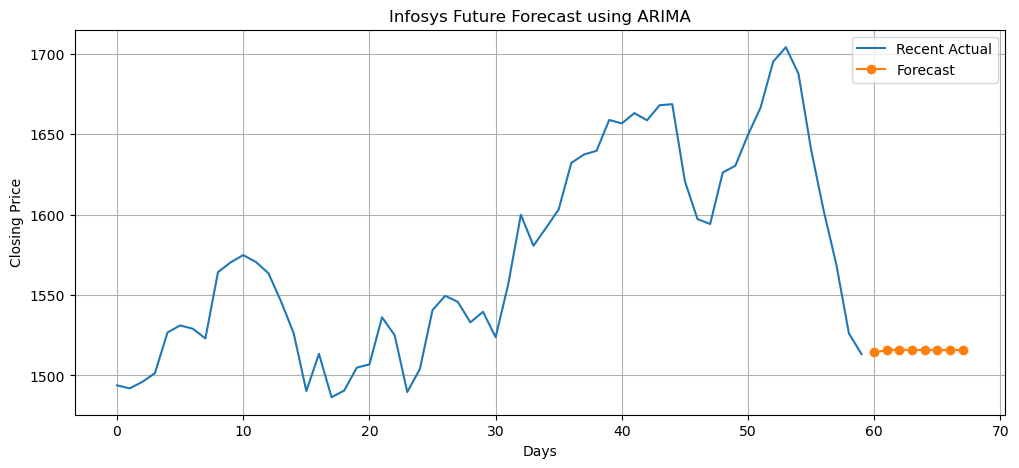

ARIMA Stock Price Forecast Completed Successfully


In [49]:
plt.figure(figsize=(12,5))
plt.plot(actual_df.tail(60).reset_index(drop=True),label="Recent Actual")

future_index=range(60,60+len(forecast_final))
plt.plot(future_index,forecast_final,marker="o",label="Forecast")

plt.title("Infosys Future Forecast using ARIMA")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

print("ARIMA Stock Price Forecast Completed Successfully")